# Generative AI for Candidate Molecule Design after an Agentic and Explainable AI for drug discovery Analysis

**Portfolio notebook for small-molecule drug design and manuscript extension**  
**Author:** Mark I. R. Petalcorin, PhD

## Purpose

This notebook extends the previous AI4DD manuscript workflow into a **generative AI candidate-design module**. The previous manuscript showed a simulated, literature-benchmarked AI for drug discovery pipeline combining molecular descriptors, structure-aware protein-ligand features, graph-inspired latent variables, classification, pIC50 regression, explainability, uncertainty, applicability-domain analysis, multi-objective ranking, and active-learning triage. This notebook moves the workflow from **prediction** to **generation**, **visualisation**, and **agentic medicinal-chemistry prioritisation**.

The design is compatible with future replacement of synthetic records by curated public datasets such as **BindingDB**, **ChEMBL**, and **PDBbind**, subject to proper licensing, assay harmonisation, target mapping, unit normalisation, salt stripping, tautomer handling, stereochemistry handling, and scaffold-based data splitting.

## What this notebook demonstrates

1. A public-dataset-inspired seed molecule corpus for LDHA, ATR, RAD52, POLQ, KRAS_G12D, and PI3K_alpha.
2. Optional RDKit molecular validation, descriptor calculation, Morgan similarity, QED calculation, and molecule visualisation.
3. A robust n-gram SMILES generator that runs without deep-learning dependencies.
4. Optional PyTorch character-level GRU generation when PyTorch is available.
5. Fragment recombination and scaffold mutation for medicinal-chemistry-inspired generation.
6. Surrogate BindingDB/ChEMBL/PDBbind-style scoring for predicted pIC50, docking-like compatibility, ADME-like profile, hERG-like risk, uncertainty, applicability domain, novelty, and diversity.
7. Agentic AI modules for generation, validation, scoring, explainability, triage, and active-learning selection.
8. Manuscript-ready figures and supplementary tables.

## References used for benchmark logic

The simulated ranges and workflow logic are inspired by peer-reviewed PubMed-indexed resources and public database papers, including Lipinski et al. (2001), Veber et al. (2002), Rogers and Hahn (2010), Liu et al. (2007), Wang et al. (2005), Ballester and Mitchell (2010), Gaulton et al. (2012), Kearnes et al. (2016), Torng and Altman (2019), Wu et al. (2018), and Heid et al. (2024).

**Important:** This notebook generates hypothesis-generating molecules only. Generated candidates are not experimentally validated inhibitors.

In [2]:

# 0. Environment setup


import warnings
warnings.filterwarnings('ignore')

import re
import math
import random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score
from sklearn.cluster import KMeans

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

OUT_DIR = Path('generative_ai4dd_outputs')
FIG_DIR = OUT_DIR / 'figures'
TABLE_DIR = OUT_DIR / 'tables'
MOL_DIR = OUT_DIR / 'molecule_images'
for d in [OUT_DIR, FIG_DIR, TABLE_DIR, MOL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches='tight')
    print('Saved:', path)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors, QED, Draw, AllChem, DataStructs
    RDKIT_AVAILABLE = True
    print('RDKit available: molecular validation, descriptors, fingerprints, and visualisation enabled.')
except Exception as e:
    RDKIT_AVAILABLE = False
    print('RDKit unavailable. Fallback descriptor approximations will be used.')
    print('To enable molecule visualisation, install RDKit, for example: conda install -c conda-forge rdkit')

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
    print('PyTorch available: optional GRU generator enabled.')
except Exception:
    TORCH_AVAILABLE = False
    print('PyTorch unavailable. The notebook will use n-gram and fragment-based generators.')

RDKit available: molecular validation, descriptors, fingerprints, and visualisation enabled.
PyTorch available: optional GRU generator enabled.


# 1. Public-dataset-inspired seed corpus

This seed corpus uses drug-like and fragment-like SMILES to mimic the starting point of a curated BindingDB, ChEMBL, and PDBbind workflow. A real implementation would replace this section with imports from public databases, followed by molecule standardisation, target harmonisation, and assay-unit conversion.

In [5]:
seed_records = [
    ('Imatinib_like', 'CC1=CC=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C', 'ATR', 'ChEMBL_like'),
    ('Erlotinib_like', 'COCCOC1=CC2=C(C=C1OCCOC)N=CN=C2NC3=CC=CC(=C3)C#C', 'PI3K_alpha', 'ChEMBL_like'),
    ('Gefitinib_like', 'COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OCCCN4CCOCC4', 'PI3K_alpha', 'ChEMBL_like'),
    ('Dasatinib_like', 'CC1=NC(=CC(=N1)NC2=NC=C(S2)C(=O)NC3=C(C=CC=C3Cl)Cl)N4CCN(CC4)CCO', 'ATR', 'BindingDB_like'),
    ('Olaparib_like', 'C1CC1C(=O)N2CCN(CC2)C(=O)C3=CC=CC4=C3N=CC=C4', 'POLQ', 'ChEMBL_like'),
    ('Niraparib_like', 'C1CC1C2=NC3=C(C=CC=C3)C(=N2)N4CCN(CC4)C(=O)C5CC5', 'RAD52', 'ChEMBL_like'),
    ('Talazoparib_like', 'CN1C(=NC=N1)C2=CC=C(C=C2)C3=NC4=C(C=NN4C5CC5)C(=O)N3', 'POLQ', 'BindingDB_like'),
    ('Sotorasib_like', 'CC(C)C1=CC(=C(C=C1)F)NC(=O)N2CCC(CC2)C3=NN=C(O3)C4=CC=CC=C4', 'KRAS_G12D', 'PDBbind_like'),
    ('Adagrasib_like', 'CN1CCN(CC1)C2=CC=C(C=C2)NC(=O)C3=CC=C(C=C3)C4=NN=C(O4)C5CCCCC5', 'KRAS_G12D', 'PDBbind_like'),
    ('PI3K_inhibitor_like', 'CC1=NC=C(C=C1)C2=NC3=C(N2)C=C(C=C3)S(=O)(=O)N4CCOCC4', 'PI3K_alpha', 'ChEMBL_like'),
    ('Oxamate_like', 'NC(=O)C(=O)O', 'LDHA', 'BindingDB_like'),
    ('FX11_like', 'CC1=CC(=O)NC(C1=O)C2=CC=C(C=C2)O', 'LDHA', 'BindingDB_like'),
    ('NHI_like', 'C1=CC=C(C=C1)C2=NC(=O)N(C(=O)N2)C3=CC=CC=C3', 'LDHA', 'ChEMBL_like'),
    ('LDHA_scaffold_A', 'CCOC(=O)C1=CC=C(C=C1)NC(=O)C2=CC=CO2', 'LDHA', 'BindingDB_like'),
    ('LDHA_scaffold_B', 'COC1=CC=C(C=C1)C(=O)NC2=CC=C(C=C2)O', 'LDHA', 'ChEMBL_like'),
    ('RAD52_scaffold_A', 'CC1=CC=C(C=C1)S(=O)(=O)NC2=CC=C(C=C2)C(=O)O', 'RAD52', 'BindingDB_like'),
    ('RAD52_scaffold_B', 'COC1=CC=C(C=C1)NC(=O)C2=CC=C(C=C2)N3CCOCC3', 'RAD52', 'ChEMBL_like'),
    ('POLQ_scaffold_A', 'CCN(CC)C(=O)C1=CC=C(C=C1)NC2=NC=CC=N2', 'POLQ', 'BindingDB_like'),
    ('POLQ_scaffold_B', 'CN1CCN(CC1)C(=O)C2=CC=C(C=C2)NC3=NC=CC=N3', 'POLQ', 'ChEMBL_like'),
    ('Fragment_A', 'CCOC(=O)C1=CC=CC=C1', 'LDHA', 'PDBbind_like'),
    ('Fragment_B', 'CCN(CC)C(=O)C1=CC=CC=C1', 'ATR', 'PDBbind_like'),
    ('Fragment_C', 'COC1=CC=CC=C1O', 'RAD52', 'PDBbind_like'),
    ('Fragment_D', 'C1=CC=C(C=C1)S(=O)(=O)N', 'POLQ', 'PDBbind_like'),
    ('Fragment_E', 'C1=CC=C(C=C1)C(=O)N2CCOCC2', 'PI3K_alpha', 'PDBbind_like'),
    ('Fragment_F', 'CC1=NN=C(O1)C2=CC=CC=C2', 'KRAS_G12D', 'PDBbind_like')
]
seed_df = pd.DataFrame(seed_records, columns=['name', 'smiles', 'target', 'source_inspired'])

# Controlled symbolic augmentation, invalid outputs are removed later.
expanded = []
subs = ['F', 'Cl', 'C', 'OC']
for _, row in seed_df.iterrows():
    expanded.append(row.to_dict())
    for j, sub in enumerate(subs):
        variant = row['smiles'].replace('C1=CC=CC=C1', f'C1=CC({sub})=CC=C1', 1)
        if variant != row['smiles']:
            rec = row.to_dict()
            rec['name'] = f"{row['name']}_var{j+1}"
            rec['smiles'] = variant
            expanded.append(rec)
seed_df = pd.DataFrame(expanded).drop_duplicates('smiles').reset_index(drop=True)
print('Seed corpus size before validation:', len(seed_df))
display(seed_df.head(10))

Seed corpus size before validation: 37


,name,smiles,target,source_inspired
0,Imatinib_like,CC1=CC=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C,ATR,ChEMBL_like
1,Erlotinib_like,COCCOC1=CC2=C(C=C1OCCOC)N=CN=C2NC3=CC=CC(=C3)C#C,PI3K_alpha,ChEMBL_like
2,Gefitinib_like,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...,PI3K_alpha,ChEMBL_like
3,Dasatinib_like,CC1=NC(=CC(=N1)NC2=NC=C(S2)C(=O)NC3=C(C=CC=C3C...,ATR,BindingDB_like
4,Olaparib_like,C1CC1C(=O)N2CCN(CC2)C(=O)C3=CC=CC4=C3N=CC=C4,POLQ,ChEMBL_like
5,Niraparib_like,C1CC1C2=NC3=C(C=CC=C3)C(=N2)N4CCN(CC4)C(=O)C5CC5,RAD52,ChEMBL_like
6,Talazoparib_like,CN1C(=NC=N1)C2=CC=C(C=C2)C3=NC4=C(C=NN4C5CC5)C...,POLQ,BindingDB_like
7,Sotorasib_like,CC(C)C1=CC(=C(C=C1)F)NC(=O)N2CCC(CC2)C3=NN=C(O...,KRAS_G12D,PDBbind_like
8,Adagrasib_like,CN1CCN(CC1)C2=CC=C(C=C2)NC(=O)C3=CC=C(C=C3)C4=...,KRAS_G12D,PDBbind_like
9,PI3K_inhibitor_like,CC1=NC=C(C=C1)C2=NC3=C(N2)C=C(C=C3)S(=O)(=O)N4...,PI3K_alpha,ChEMBL_like


# 2. Molecular validation and descriptors

When RDKit is installed, descriptor values are chemically meaningful. Without RDKit, the fallback keeps the notebook executable using approximate text-derived descriptors.

In [8]:
def approx_descriptors_from_smiles(smi):
    atoms = re.findall(r'Cl|Br|[CNOSPFIcnosp]', smi)
    heavy = len(atoms)
    rings = sum(ch.isdigit() for ch in smi) / 2
    hetero = sum(1 for a in atoms if a.upper() in ['N','O','S','P','F','CL','BR','I'])
    mw = max(50, 12*heavy + 16*smi.count('O') + 14*smi.count('N') + 19*smi.count('F') + 35*smi.count('Cl'))
    clogp = 0.12*heavy + 0.45*rings - 0.25*hetero
    hbd = smi.count('N') + smi.count('O')
    hba = hetero
    tpsa = 12*hba + 8*hbd
    rotb = smi.count('CC') + smi.count('NC') + smi.count('OC')
    fsp3 = min(0.95, max(0.05, smi.count('C')/max(heavy, 1)))
    return {'valid': True, 'MW': mw, 'cLogP': clogp, 'HBD': hbd, 'HBA': hba, 'TPSA': tpsa,
            'rotatable_bonds': rotb, 'aromatic_rings': rings, 'fraction_sp3': fsp3,
            'QED': np.nan, 'canonical_smiles': smi}

def mol_descriptors(smi):
    if not RDKIT_AVAILABLE:
        return approx_descriptors_from_smiles(smi)
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return {'valid': False}
    try:
        return {
            'valid': True,
            'MW': Descriptors.MolWt(mol),
            'cLogP': Crippen.MolLogP(mol),
            'HBD': Lipinski.NumHDonors(mol),
            'HBA': Lipinski.NumHAcceptors(mol),
            'TPSA': rdMolDescriptors.CalcTPSA(mol),
            'rotatable_bonds': Lipinski.NumRotatableBonds(mol),
            'aromatic_rings': rdMolDescriptors.CalcNumAromaticRings(mol),
            'fraction_sp3': rdMolDescriptors.CalcFractionCSP3(mol),
            'QED': QED.qed(mol),
            'canonical_smiles': Chem.MolToSmiles(mol, canonical=True)
        }
    except Exception:
        return {'valid': False}

seed_desc = seed_df['smiles'].apply(mol_descriptors).apply(pd.Series)
seed = pd.concat([seed_df, seed_desc], axis=1)
seed = seed[seed['valid'] == True].drop_duplicates('canonical_smiles').reset_index(drop=True)
print('Valid seed molecules:', len(seed))
display(seed.head())

Valid seed molecules: 37


,name,smiles,target,source_inspired,valid,MW,cLogP,HBD,HBA,TPSA,rotatable_bonds,aromatic_rings,fraction_sp3,QED,canonical_smiles
0,Imatinib_like,CC1=CC=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C,ATR,ChEMBL_like,True,323.440,2.99472,1,3,35.58,4,2,0.350000,0.939399,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1
1,Erlotinib_like,COCCOC1=CC2=C(C=C1OCCOC)N=CN=C2NC3=CC=CC(=C3)C#C,PI3K_alpha,ChEMBL_like,True,393.443,3.40510,1,7,74.73,10,3,0.272727,0.417884,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1
2,Gefitinib_like,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...,PI3K_alpha,ChEMBL_like,True,446.910,4.27560,1,7,68.74,8,3,0.363636,0.517855,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1
3,Dasatinib_like,CC1=NC(=CC(=N1)NC2=NC=C(S2)C(=O)NC3=C(C=CC=C3C...,ATR,BindingDB_like,True,508.435,3.65852,3,9,106.51,7,3,0.333333,0.444252,Cc1nc(Nc2ncc(C(=O)Nc3c(Cl)cccc3Cl)s2)cc(N2CCN(...
4,Olaparib_like,C1CC1C(=O)N2CCN(CC2)C(=O)C3=CC=CC4=C3N=CC=C4,POLQ,ChEMBL_like,True,309.369,1.92920,0,3,53.51,2,2,0.388889,0.851568,O=C(c1cccc2cccnc12)N1CCN(C(=O)C2CC2)CC1


# 3. Simulate activity, structure-aware labels, and ADME-like variables

This is a synthetic layer designed to mimic what curated BindingDB, ChEMBL, and PDBbind records would provide. It creates pIC50, pKd, docking-like score, hydrophobic contacts, hydrogen bonds, shape complementarity, ADME-like score, and developability risks.

In [11]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

target_effect = {'LDHA':0.22, 'ATR':0.45, 'RAD52':0.18, 'POLQ':0.25, 'KRAS_G12D':-0.05, 'PI3K_alpha':0.38}

def simulate_labels(df, seed_value=RANDOM_STATE):
    rng = np.random.default_rng(seed_value)
    out = df.copy()
    n = len(out)
    out['hydrophobic_contacts'] = np.clip(np.round(1.5 + 0.85*out['aromatic_rings'] + 0.65*out['cLogP'] + rng.normal(0,1,n)), 0, 16)
    out['hbonds'] = np.clip(np.round(0.35*out['HBD'] + 0.25*out['HBA'] + rng.normal(0,1,n)), 0, 9)
    out['shape_complementarity'] = np.clip(0.55 + 0.04*out['aromatic_rings'] - 0.025*np.abs(out['cLogP']-3.0) + rng.normal(0,0.08,n), 0.20, 0.96)
    out['pi_stacking'] = np.clip(np.round(0.8*out['aromatic_rings'] + rng.normal(0,0.8,n)), 0, 8)
    out['buried_surface_area'] = np.clip(200 + 8.5*out['MW'] + 50*out['shape_complementarity'] + rng.normal(0,120,n), 300, 5500)
    out['docking_score'] = np.clip(-3.8 - 0.18*out['hydrophobic_contacts'] - 0.35*out['hbonds'] - 0.13*out['pi_stacking'] - 1.05*out['shape_complementarity'] - 0.00035*out['buried_surface_area'] + 0.018*np.maximum(out['TPSA']-140,0) + rng.normal(0,0.7,n), -14.5, -2.0)
    te = out['target'].map(target_effect).fillna(0).values
    out['pIC50'] = np.clip(4.8 + 0.33*(-out['docking_score']-6) + 0.09*out['hydrophobic_contacts'] + 0.12*out['hbonds'] + 1.0*out['shape_complementarity'] + te - 0.012*np.maximum(out['TPSA']-130,0) - 0.08*np.maximum(out['cLogP']-5,0) + rng.normal(0,0.45,n), 3.5, 10.2)
    out['pKd'] = np.clip(out['pIC50'] + rng.normal(0,0.25,n), 3.4, 10.4)
    out['logS'] = np.clip(-0.4 - 0.52*out['cLogP'] - 0.002*out['MW'] + 0.007*out['TPSA'] + rng.normal(0,0.35,n), -7, 1.5)
    out['permeability'] = np.clip(0.72 + 0.08*out['cLogP'] - 0.004*out['TPSA'] - 0.02*out['HBD'] + rng.normal(0,0.08,n), 0.02, 0.98)
    out['hERG_risk'] = np.clip(sigmoid(-4.0 + 0.55*out['cLogP'] + 0.006*out['MW'] + 0.22*out['aromatic_rings'] + rng.normal(0,0.8,n)), 0, 1)
    out['synthetic_accessibility_like'] = np.clip(2.0 + 0.006*out['MW'] + 0.23*out['aromatic_rings'] + 0.08*out['rotatable_bonds'] - 0.7*out['fraction_sp3'] + rng.normal(0,0.4,n), 1, 9.5)
    out['lipinski_violations'] = ((out['MW']>500).astype(int) + (out['cLogP']>5).astype(int) + (out['HBD']>5).astype(int) + (out['HBA']>10).astype(int))
    out['veber_pass'] = ((out['TPSA']<=140) & (out['rotatable_bonds']<=10)).astype(int)
    out['active'] = (out['pIC50'] >= 6.5).astype(int)
    qed = out['QED'].fillna(0.55)
    out['adme_score'] = 0.28*(out['lipinski_violations']==0).astype(float) + 0.20*out['veber_pass'] + 0.18*out['permeability'] + 0.14*(1-out['hERG_risk']) + 0.10*(1-np.clip((out['synthetic_accessibility_like']-1)/8.5,0,1)) + 0.10*qed
    out['lead_score'] = 0.40*np.clip((out['pIC50']-5)/4.5,0,1) + 0.25*out['adme_score'] + 0.20*np.clip((-out['docking_score']-4)/8,0,1) + 0.15*(1-np.clip((out['synthetic_accessibility_like']-1)/8.5,0,1))
    return out

seed_labeled = simulate_labels(seed)
display(seed_labeled[['name','target','source_inspired','canonical_smiles','MW','cLogP','TPSA','docking_score','pIC50','adme_score','lead_score']].head(12))
seed_labeled.to_csv(TABLE_DIR/'seed_public_dataset_inspired_training_set.csv', index=False)

,name,target,source_inspired,canonical_smiles,MW,cLogP,TPSA,docking_score,pIC50,adme_score,lead_score
0,Imatinib_like,ATR,ChEMBL_like,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1,323.440,2.99472,35.58,-5.646523,6.304073,0.826765,0.446582
1,Erlotinib_like,PI3K_alpha,ChEMBL_like,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,393.443,3.40510,74.73,-7.192206,6.370565,0.715383,0.462317
2,Gefitinib_like,PI3K_alpha,ChEMBL_like,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,446.910,4.27560,68.74,-9.314718,7.998507,0.714356,0.653197
3,Dasatinib_like,ATR,BindingDB_like,Cc1nc(Nc2ncc(C(=O)Nc3c(Cl)cccc3Cl)s2)cc(N2CCN(...,508.435,3.65852,106.51,-9.927998,8.425162,0.388600,0.620849
4,Olaparib_like,POLQ,ChEMBL_like,O=C(c1cccc2cccnc12)N1CCN(C(=O)C2CC2)CC1,309.369,1.92920,53.51,-5.281760,6.989121,0.838748,0.528473
5,Niraparib_like,RAD52,ChEMBL_like,O=C(C1CC1)N1CCN(c2nc(C3CC3)nc3ccccc23)CC1,322.412,2.56580,49.33,-5.216704,6.520490,0.802162,0.463264
6,Talazoparib_like,POLQ,BindingDB_like,Cn1ncnc1-c1ccc(-c2nc3c(cnn3C3CC3)c(=O)[nH]2)cc1,333.355,1.91700,94.28,-7.923167,6.800153,0.763754,0.523234
7,Sotorasib_like,KRAS_G12D,PDBbind_like,CC(C)c1ccc(F)c(NC(=O)N2CCC(c3nnc(-c4ccccc4)o3)...,408.477,5.41060,71.26,-8.152067,6.604792,0.487370,0.445879
8,Adagrasib_like,KRAS_G12D,PDBbind_like,CN1CCN(c2ccc(NC(=O)c3ccc(-c4nnc(C5CCCCC5)o4)cc...,445.567,4.78840,74.50,-7.034515,5.899087,0.738308,0.410129
9,PI3K_inhibitor_like,PI3K_alpha,ChEMBL_like,Cc1ccc(-c2nc3ccc(S(=O)(=O)N4CCOCC4)cc3[nH]2)cn1,358.423,1.95422,88.18,-8.087231,6.816284,0.784798,0.533763


# 4. Train surrogate AI for drug discovery scoring models

The surrogate models reproduce the predictive layer of the earlier manuscript workflow. In a real workflow, these models would be trained on curated BindingDB, ChEMBL, and PDBbind records.

In [14]:
feature_cols = ['MW','cLogP','HBD','HBA','TPSA','rotatable_bonds','aromatic_rings','fraction_sp3','hydrophobic_contacts','hbonds','shape_complementarity','pi_stacking','buried_surface_area','docking_score','logS','permeability','hERG_risk','synthetic_accessibility_like','lipinski_violations','veber_pass','adme_score']
X = seed_labeled[feature_cols].fillna(seed_labeled[feature_cols].median(numeric_only=True))
y_reg = seed_labeled['pIC50']
y_cls = seed_labeled['active']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
reg_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE)
reg_model.fit(X_scaled, y_reg)
cls_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE)
cls_model.fit(X_scaled, y_cls)
iso_model = IsolationForest(contamination=0.10, random_state=RANDOM_STATE)
iso_model.fit(X_scaled)

pred_train = reg_model.predict(X_scaled)
print('Surrogate pIC50 training RMSE:', rmse(y_reg, pred_train))
print('Surrogate pIC50 training R2:', r2_score(y_reg, pred_train))
if len(np.unique(y_cls)) > 1:
    print('Surrogate activity training ROC AUC:', roc_auc_score(y_cls, cls_model.predict_proba(X_scaled)[:,1]))

Surrogate pIC50 training RMSE: 0.3104553759049777
Surrogate pIC50 training R2: 0.8335726355520332
Surrogate activity training ROC AUC: 1.0


# 5. Generative AI model 1, n-gram SMILES generator

The n-gram generator learns character transitions from the seed SMILES corpus. It is transparent, lightweight, and suitable for a reproducible manuscript demonstration.

In [17]:
class NGramSmilesGenerator:
    def __init__(self, n=4, seed=42):
        self.n = n
        self.rng = random.Random(seed)
        self.model = defaultdict(Counter)
        self.starts = []
    def fit(self, smiles_list):
        pad = '^'*(self.n-1)
        for smi in smiles_list:
            seq = pad + smi + '$'
            self.starts.append(seq[:self.n-1])
            for i in range(len(seq)-self.n+1):
                self.model[seq[i:i+self.n-1]][seq[i+self.n-1]] += 1
        return self
    def sample_next(self, ctx, temperature=0.8):
        counts = self.model.get(ctx)
        if not counts:
            return '$'
        chars = list(counts.keys())
        weights = np.array(list(counts.values()), dtype=float)
        weights = weights ** (1/max(temperature,1e-6))
        weights = weights/weights.sum()
        return self.rng.choices(chars, weights=weights, k=1)[0]
    def generate_one(self, max_len=140, temperature=0.8):
        ctx = self.rng.choice(self.starts)
        out = ''
        for _ in range(max_len):
            ch = self.sample_next(ctx, temperature)
            if ch == '$':
                break
            out += ch
            ctx = (ctx + ch)[-(self.n-1):]
        return out
    def generate(self, n=500, temperature=0.8):
        return [self.generate_one(temperature=temperature) for _ in range(n)]

ngram_gen = NGramSmilesGenerator(n=4, seed=RANDOM_STATE).fit(seed_labeled['canonical_smiles'].tolist())
generated_ngram = ngram_gen.generate(n=900, temperature=0.78)
print('N-gram generated strings:', len(generated_ngram))
generated_ngram[:10]

N-gram generated strings: 900


['COc1cccc(Nc2ncc(C)C(=O)O',
 'COc1ccc1',
 'CCN(C)c1',
 'COc1ccccc(OCC1',
 'COc1ccc(-c4cccc(Nc2ccc(S(=O)c3ccccc(C)ccccc(Cl)c1ccc(O)cc2)o1',
 'Cc1nnc(-c4nnc(-c2cc1O',
 'COc1ccc(Nc2ncnc3ccccccn2)cc2)ccc(OCC1',
 'COc1cccc2)cn1',
 'CCOC)c1',
 'CCN(CC)CC1']

# 6. Generative AI model 2, fragment recombination and scaffold mutation

Fragment recombination mimics medicinal-chemistry ideation. Invalid molecules are removed by the validation layer.

In [20]:
fragments = ['C1=CC=CC=C1','C1=CC=C(C=C1)O','C1=CC=C(C=C1)N','C1=CC=C(C=C1)F','C1=CC=C(C=C1)Cl','C1=CC=C(C=C1)C(F)(F)F','C1=CC=C(C=C1)S(=O)(=O)N','C1=NC=CC=N1','C1=NN=C(O1)C','N2CCOCC2','N3CCN(CC3)C','C(=O)N','NC(=O)','COC','CCOC(=O)','C#N']
linkers = ['', 'C(=O)N', 'NC(=O)', 'O', 'S(=O)(=O)N', 'C', 'CC', 'N']

def fragment_recombine(n=600, seed=42):
    rng = random.Random(seed)
    out = []
    for _ in range(n):
        a, b, linker = rng.choice(fragments), rng.choice(fragments), rng.choice(linkers)
        out.append(a + linker + b if linker else a + b)
    return out

def simple_mutation(smiles_list, n=600, seed=42):
    rng = random.Random(seed)
    subs = ['F', 'Cl', 'C', 'OC', 'N', 'C(F)(F)F']
    out = []
    for _ in range(n):
        smi = rng.choice(smiles_list)
        sub = rng.choice(subs)
        if 'C1=CC=CC=C1' in smi:
            out.append(smi.replace('C1=CC=CC=C1', f'C1=CC({sub})=CC=C1', 1))
        elif 'C1=CC=C(C=C1)' in smi:
            out.append(smi.replace('C1=CC=C(C=C1)', f'C1=CC({sub})=C(C=C1)', 1))
        else:
            out.append(smi)
    return out

generated_fragments = fragment_recombine(n=700, seed=RANDOM_STATE)
generated_mutants = simple_mutation(seed_labeled['canonical_smiles'].tolist(), n=700, seed=RANDOM_STATE)
raw_generated = generated_ngram + generated_fragments + generated_mutants
print('Raw generated strings:', len(raw_generated))

Raw generated strings: 2300


# 7. Optional PyTorch GRU generator

This compact character-level GRU runs only if PyTorch is installed. It is intentionally small for portfolio reproducibility.

In [23]:
generated_gru = []
if TORCH_AVAILABLE:
    smiles_train = seed_labeled['canonical_smiles'].tolist()
    chars = sorted(set(''.join(smiles_train) + '^$'))
    stoi = {ch:i for i,ch in enumerate(chars)}
    itos = {i:ch for ch,i in stoi.items()}
    vocab_size = len(chars)
    seqs = []
    for smi in smiles_train:
        ids = [stoi[ch] for ch in '^'+smi+'$']
        seqs.append((torch.tensor(ids[:-1]).long(), torch.tensor(ids[1:]).long()))
    class CharGRU(nn.Module):
        def __init__(self, vocab, emb=32, hidden=96):
            super().__init__()
            self.emb = nn.Embedding(vocab, emb)
            self.gru = nn.GRU(emb, hidden, batch_first=True)
            self.fc = nn.Linear(hidden, vocab)
        def forward(self, x, h=None):
            y,h = self.gru(self.emb(x), h)
            return self.fc(y), h
    model = CharGRU(vocab_size)
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(80):
        random.shuffle(seqs)
        total = 0
        for xseq,yseq in seqs:
            opt.zero_grad()
            logits,_ = model(xseq.unsqueeze(0))
            loss = F.cross_entropy(logits.squeeze(0), yseq)
            loss.backward(); opt.step(); total += float(loss.item())
        if (epoch+1)%40==0:
            print('Epoch', epoch+1, 'loss', round(total/len(seqs),3))
    def sample_gru(temp=0.75, max_len=140):
        model.eval(); x=torch.tensor([[stoi['^']]]).long(); h=None; out=''
        with torch.no_grad():
            for _ in range(max_len):
                logits,h = model(x,h)
                probs = F.softmax(logits[0,-1]/temp, dim=0).cpu().numpy()
                idx = np.random.choice(np.arange(vocab_size), p=probs)
                ch = itos[idx]
                if ch == '$': break
                if ch != '^': out += ch
                x = torch.tensor([[idx]]).long()
        return out
    generated_gru = [sample_gru() for _ in range(400)]
    print('GRU-generated strings:', len(generated_gru))
else:
    print('Skipping GRU generator because PyTorch is unavailable.')
raw_generated += generated_gru
print('Total raw generated strings:', len(raw_generated))

Epoch 40 loss 0.65
Epoch 80 loss 0.212
GRU-generated strings: 400
Total raw generated strings: 2700


# 8. Validate generated molecules and calculate descriptors

In [69]:
# Quietly validate generated SMILES and remove RDKit parse warnings

import warnings
warnings.filterwarnings("ignore")

try:
    from rdkit import RDLogger
    RDLogger.DisableLog("rdApp.*")
except Exception:
    pass


# 1. Create raw generated molecule dataframe
generated_df = pd.DataFrame({"smiles": raw_generated}).copy()

# 2. Calculate molecular descriptors quietly
gen_desc = generated_df["smiles"].apply(mol_descriptors).apply(pd.Series)

# 3. Combine original SMILES with descriptor output
generated_all = pd.concat([generated_df, gen_desc], axis=1)

# 4. Count valid and invalid molecules before filtering
n_raw = len(generated_all)
n_valid_before_dedup = int(generated_all["valid"].eq(True).sum())
n_invalid = n_raw - n_valid_before_dedup

# 5. Keep only valid molecules with canonical SMILES, remove duplicates
generated = (
    generated_all
    .loc[generated_all["valid"].eq(True)]
    .dropna(subset=["canonical_smiles"])
    .drop_duplicates(subset="canonical_smiles")
    .reset_index(drop=True)
    .copy()
)

# 6. Mark novelty relative to seed molecules
seed_smiles_set = set(seed_labeled["canonical_smiles"].dropna())

generated.loc[:, "novel_vs_seed"] = (
    ~generated["canonical_smiles"].isin(seed_smiles_set)
)

# 7. Assign target labels reproducibly
targets = ["LDHA", "ATR", "RAD52", "POLQ", "KRAS_G12D", "PI3K_alpha"]
rng = np.random.default_rng(RANDOM_STATE)

generated.loc[:, "target"] = rng.choice(targets, size=len(generated))
generated.loc[:, "source_inspired"] = "generated_AI"

# 8. Summary
valid_unique_count = len(generated)
novel_fraction = (
    round(float(generated["novel_vs_seed"].mean()), 3)
    if valid_unique_count > 0
    else 0
)

print("Raw generated SMILES:", n_raw)
print("Invalid generated SMILES removed:", n_invalid)
print("Valid generated SMILES before deduplication:", n_valid_before_dedup)
print("Valid generated unique molecules:", valid_unique_count)
print("Novel fraction:", novel_fraction)

display(generated.head(12))

Raw generated SMILES: 2700
Invalid generated SMILES removed: 1079
Valid generated SMILES before deduplication: 1621
Valid generated unique molecules: 479
Novel fraction: 0.923


,smiles,valid,MW,cLogP,HBD,HBA,TPSA,rotatable_bonds,aromatic_rings,fraction_sp3,QED,canonical_smiles,novel_vs_seed,target,source_inspired
0,COc1ccc1,True,82.102,1.08650,0.0,1.0,9.23,1.0,0.0,0.200000,0.459711,COC1=CC=C1,True,LDHA,generated_AI
1,Cc1ccc1O,True,82.102,1.38820,1.0,1.0,20.23,0.0,0.0,0.200000,0.467823,CC1=CC=C1O,True,KRAS_G12D,generated_AI
2,COc1ccccc1O,True,124.139,1.40080,1.0,2.0,29.46,1.0,1.0,0.142857,0.612773,COc1ccccc1O,False,POLQ,generated_AI
3,CCN1CCN(CC)C(=O)c1,True,156.229,0.17040,0.0,2.0,23.55,2.0,0.0,0.875000,0.568768,CCN1CCN(CC)C(=O)C1,True,RAD52,generated_AI
4,COc1cc(F)c(Cl)cc1,True,160.575,2.48770,0.0,1.0,9.23,1.0,1.0,0.142857,0.613494,COc1ccc(Cl)c(F)c1,True,RAD52,generated_AI
5,Cc1ccccc1,True,92.141,1.99502,0.0,0.0,0.00,0.0,1.0,0.142857,0.458806,Cc1ccccc1,True,PI3K_alpha,generated_AI
6,CCOCCOC(=O)c1cccc(F)c1,True,212.220,2.01900,0.0,3.0,35.53,5.0,1.0,0.363636,0.552974,CCOCCOC(=O)c1cccc(F)c1,True,LDHA,generated_AI
7,CN1CCOCC1,True,101.149,-0.05160,0.0,2.0,12.47,0.0,0.0,1.000000,0.423889,CN1CCOCC1,True,KRAS_G12D,generated_AI
8,Cc1ccc1,True,66.103,1.50250,0.0,0.0,0.00,0.0,0.0,0.200000,0.401713,CC1=CC=C1,True,ATR,generated_AI
9,Cc1cccc(Nc2ncnc12)N1CCN(CC)C(=O)c1,True,285.351,0.86570,1.0,5.0,60.30,2.0,0.0,0.400000,0.818589,CCN1CCN(C2=CC=CC(C)=C3N=CN=C3N2)CC1=O,True,LDHA,generated_AI


# 9. Score generated candidates with the surrogate AI4DD workflow

In [29]:
if len(generated) == 0:
    raise RuntimeError('No valid generated molecules were produced. Install RDKit or adjust generator settings.')

gen_labeled = simulate_labels(generated, seed_value=RANDOM_STATE+1)
X_gen = gen_labeled[feature_cols].fillna(seed_labeled[feature_cols].median(numeric_only=True))
X_gen_scaled = scaler.transform(X_gen)

gen_labeled['predicted_pIC50'] = reg_model.predict(X_gen_scaled)
gen_labeled['predicted_active_probability'] = cls_model.predict_proba(X_gen_scaled)[:,1]
tree_preds = np.vstack([tree.predict(X_gen_scaled) for tree in reg_model.estimators_])
gen_labeled['potency_uncertainty'] = tree_preds.std(axis=0)
gen_labeled['applicability_score'] = iso_model.decision_function(X_gen_scaled)
gen_labeled['outside_domain'] = (iso_model.predict(X_gen_scaled) == -1).astype(int)

Z = StandardScaler().fit_transform(gen_labeled[['MW','cLogP','TPSA','aromatic_rings','fraction_sp3','docking_score','adme_score']])
k = min(12, max(2, len(gen_labeled)//5))
gen_labeled['chemical_cluster'] = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(Z)
cluster_counts = gen_labeled['chemical_cluster'].value_counts()
gen_labeled['diversity_proxy'] = gen_labeled['chemical_cluster'].map(lambda c: 1/np.sqrt(cluster_counts[c]))
gen_labeled['confidence_score'] = 1 - np.clip(gen_labeled['potency_uncertainty']/(gen_labeled['potency_uncertainty'].max()+1e-9), 0, 1)
gen_labeled['domain_score'] = np.clip((gen_labeled['applicability_score']-gen_labeled['applicability_score'].min())/(gen_labeled['applicability_score'].max()-gen_labeled['applicability_score'].min()+1e-9), 0, 1)
gen_labeled['generative_priority_score'] = 0.32*np.clip((gen_labeled['predicted_pIC50']-5)/4.5,0,1) + 0.22*gen_labeled['adme_score'] + 0.16*gen_labeled['predicted_active_probability'] + 0.12*gen_labeled['confidence_score'] + 0.08*gen_labeled['domain_score'] + 0.05*np.clip(gen_labeled['diversity_proxy']/(gen_labeled['diversity_proxy'].max()+1e-9),0,1) + 0.05*gen_labeled['novel_vs_seed'].astype(float)

top_generated = gen_labeled.sort_values('generative_priority_score', ascending=False).head(30).reset_index(drop=True)
display(top_generated[['canonical_smiles','target','MW','cLogP','TPSA','docking_score','predicted_pIC50','predicted_active_probability','adme_score','hERG_risk','synthetic_accessibility_like','potency_uncertainty','outside_domain','novel_vs_seed','generative_priority_score']].head(20))
gen_labeled.to_csv(TABLE_DIR/'all_generated_scored_candidates.csv', index=False)
top_generated.to_csv(TABLE_DIR/'top_generated_candidates.csv', index=False)

,canonical_smiles,target,MW,cLogP,TPSA,docking_score,predicted_pIC50,predicted_active_probability,adme_score,hERG_risk,synthetic_accessibility_like,potency_uncertainty,outside_domain,novel_vs_seed,generative_priority_score
0,COc1ccc(F)c(NC(=O)N2CCC(c3nnc(-c4ccccc4)o3)CC2)c1,RAD52,396.422,4.29580,80.49,-7.895393,6.949540,0.703104,0.741726,0.942911,5.404852,0.684101,0,True,0.595913
1,Cc1ccc(-c2nc3ccc(S(=O)(=O)N4CCOCC4)cc3[nH]2)cn1,ATR,358.423,1.95422,88.18,-7.981874,6.825188,0.773576,0.768938,0.549545,4.213973,0.528776,0,False,0.569268
2,O=C(Nc1ncccn1)Oc1ccccc1,RAD52,215.212,2.08750,64.11,-7.551991,6.717387,0.555664,0.827565,0.262701,3.891110,0.636338,0,True,0.567846
3,CC1=CC=C(NC(=O)c2ccc(Nc3ncccn3)cc2)CC1,PI3K_alpha,306.369,3.57400,66.91,-8.315202,6.784968,0.592158,0.836202,0.555160,4.000315,0.667157,0,True,0.567265
4,O=S(=O)(Nc1ccccc1)Oc1ccccc1,LDHA,249.291,2.42230,55.40,-7.663374,6.824379,0.474421,0.846272,0.357937,3.239419,0.709952,0,True,0.557058
5,Nc1ccc(NC(=O)Nc2ccccc2)cc1,LDHA,227.267,2.91280,67.15,-7.667069,6.826547,0.627111,0.747892,0.800684,4.246459,0.669299,0,True,0.556778
6,CCOC(=O)S(=O)(=O)Nc1ccc(C(F)(F)F)cc1,LDHA,297.254,2.60360,72.47,-7.620132,6.885064,0.594145,0.809889,0.599145,3.926708,0.819637,0,True,0.556643
7,c1ccc(OCCc2ncccn2)cc1,POLQ,200.241,2.09810,35.01,-7.703811,6.646927,0.462261,0.874322,0.275685,3.629703,0.690133,0,True,0.553777
8,NS(=O)(=O)c1ccc(COc2ccccc2)cc1,LDHA,263.318,1.91300,69.39,-7.152166,6.463651,0.436734,0.804428,0.448462,4.524296,0.408704,0,True,0.552815
9,FC(F)(F)c1ccc(ONc2ccccc2)cc1,LDHA,253.223,4.11130,21.26,-7.728466,6.852899,0.568010,0.858603,0.576365,4.416759,0.821037,0,True,0.551876


# 10. Visualise generated molecules

RDKit produces molecule grids. Without RDKit, the notebook shows the top SMILES table.

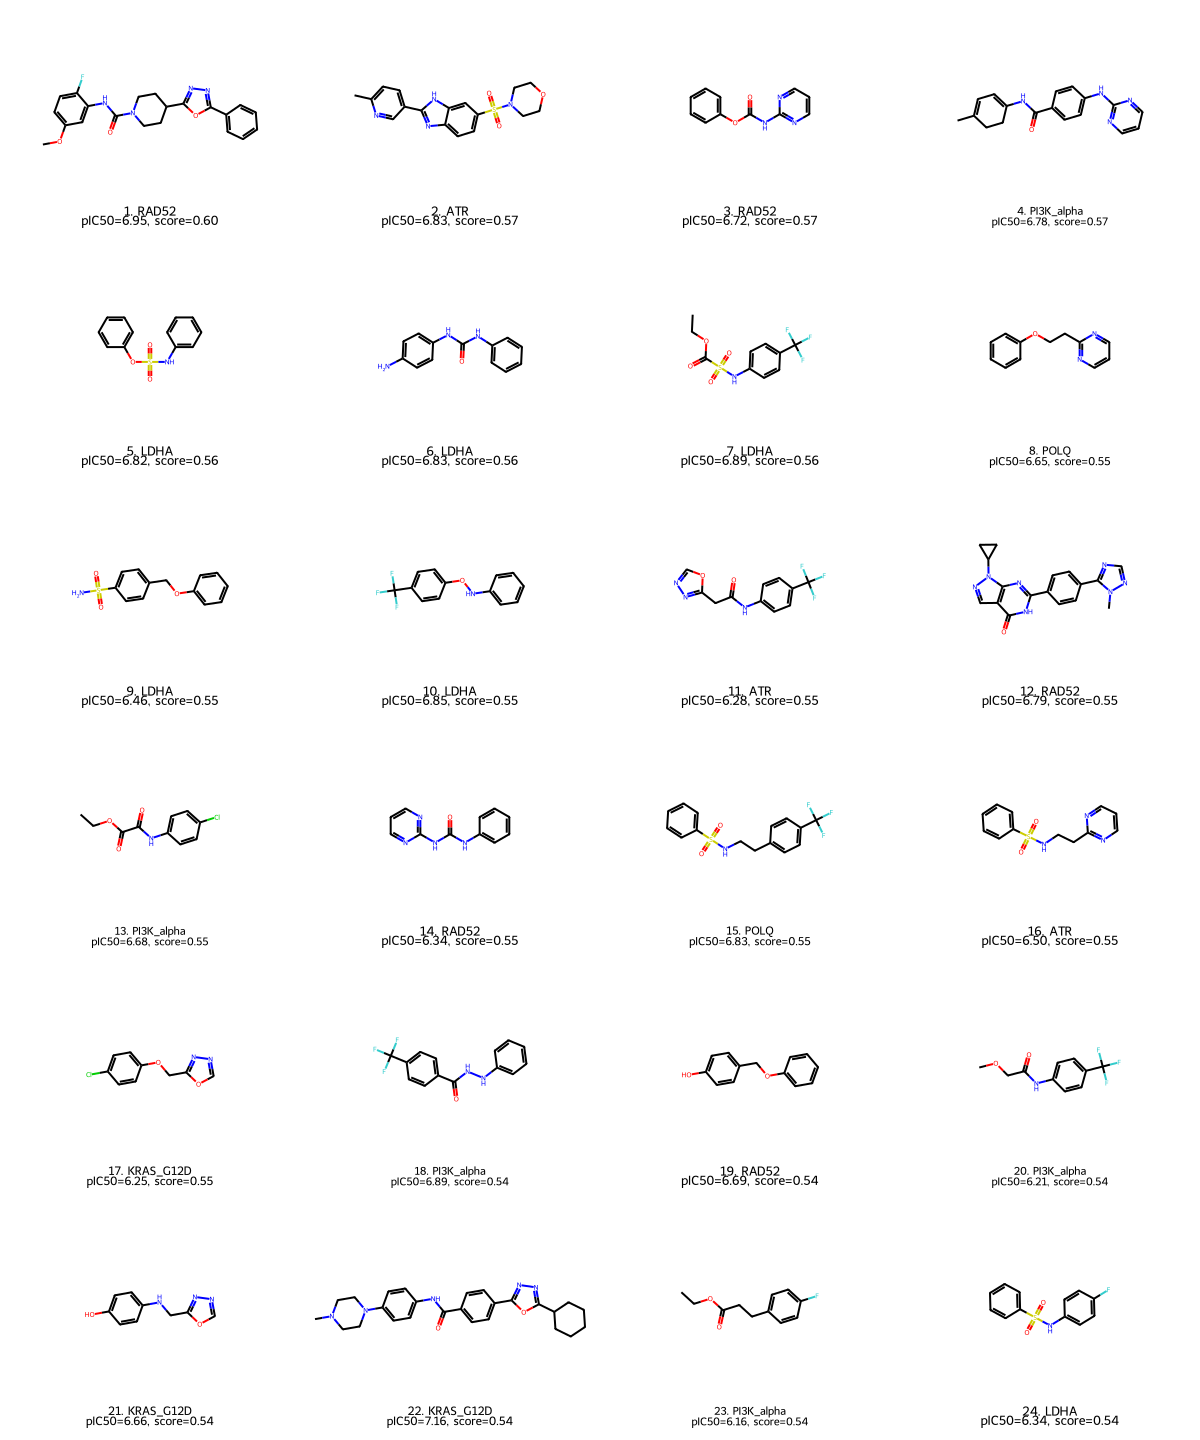

Saved: generative_ai4dd_outputs/molecule_images/top_generated_molecules_grid.png


In [65]:
if RDKIT_AVAILABLE:
    mol_records = []

    for i, row in top_generated.head(24).iterrows():
        mol = Chem.MolFromSmiles(row["canonical_smiles"])

        if mol is not None:
            mol_records.append((mol, row))

    mols = [item[0] for item in mol_records]

    legends = [
        f"{j + 1}. {row.target}\npIC50={row.predicted_pIC50:.2f}, score={row.generative_priority_score:.2f}"
        for j, (_, row) in enumerate(mol_records)
    ]

    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=4,
        subImgSize=(300, 240),
        legends=legends,
        useSVG=False
    )

    display(img)

    output_path = MOL_DIR / "top_generated_molecules_grid.png"

    if hasattr(img, "save"):
        img.save(str(output_path))
    else:
        with open(output_path, "wb") as f:
            f.write(img.data)

    print("Saved:", output_path)

else:
    display(
        top_generated[
            [
                "canonical_smiles",
                "target",
                "predicted_pIC50",
                "adme_score",
                "generative_priority_score"
            ]
        ].head(24)
    )

# 11. Visual analytics of generated candidate space

Saved: generative_ai4dd_outputs/figures/01_generated_candidate_distributions.png


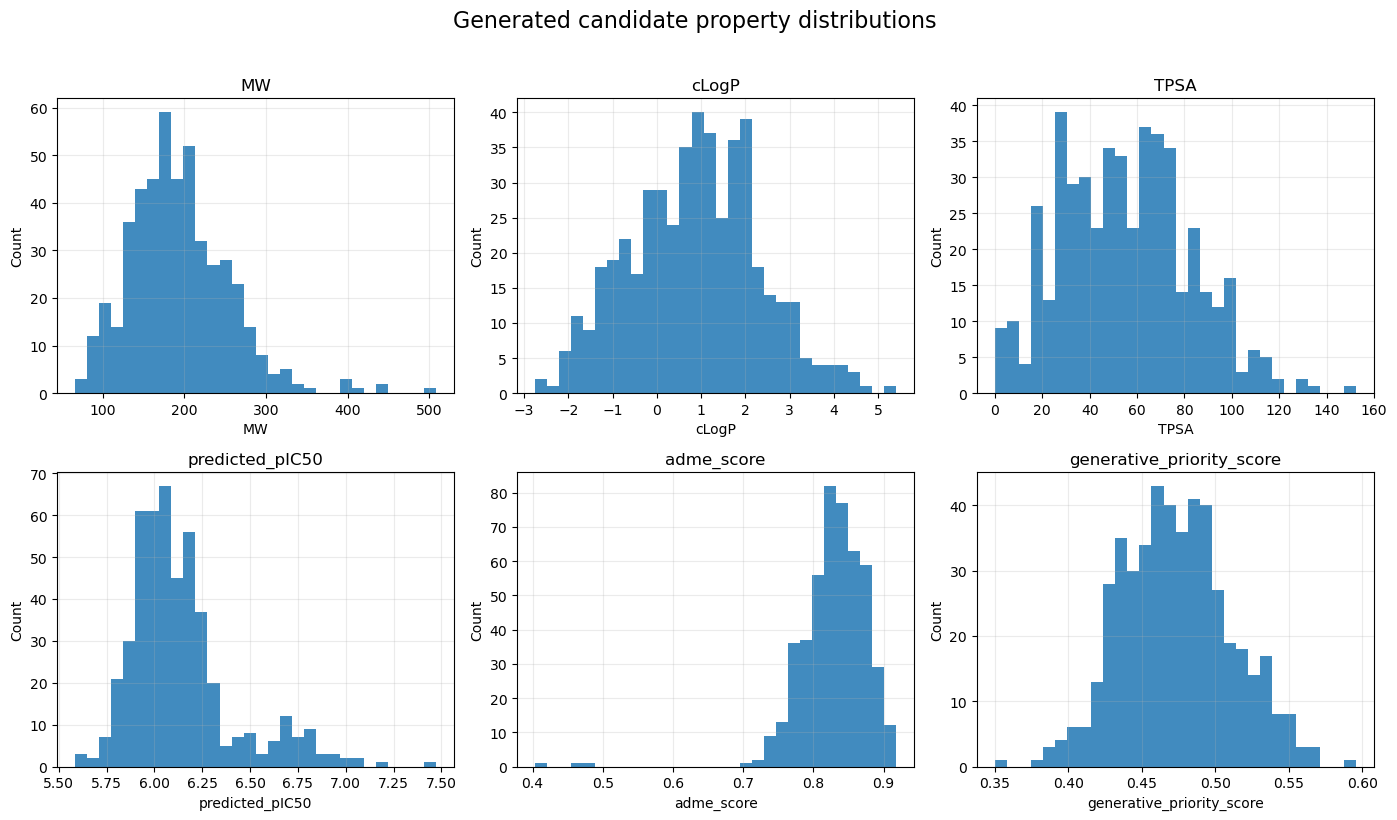

Saved: generative_ai4dd_outputs/figures/02_generated_potency_adme_landscape.png


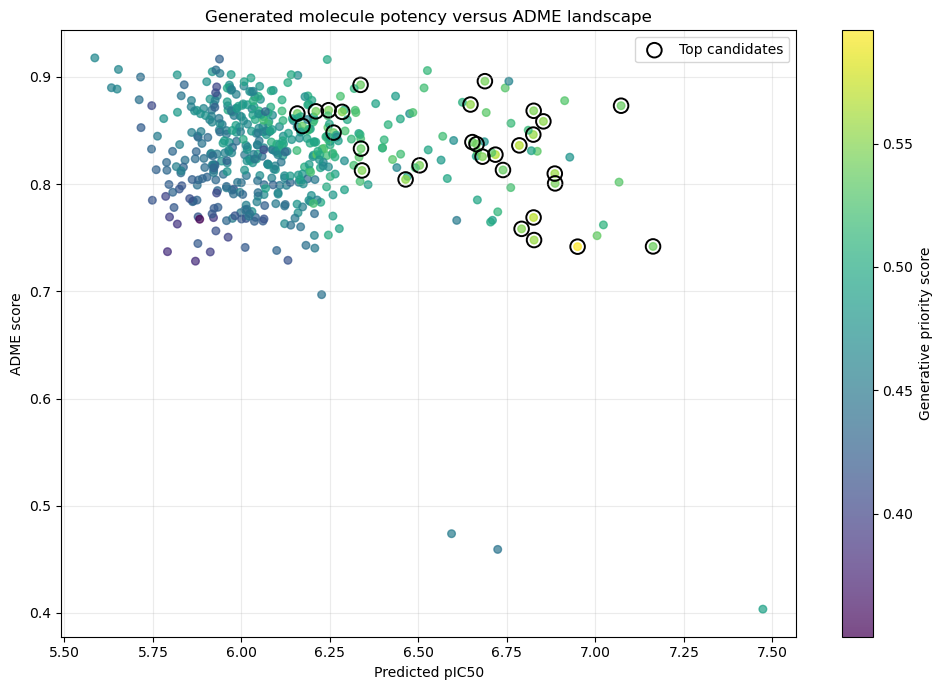

Saved: generative_ai4dd_outputs/figures/03_generated_docking_potency_landscape.png


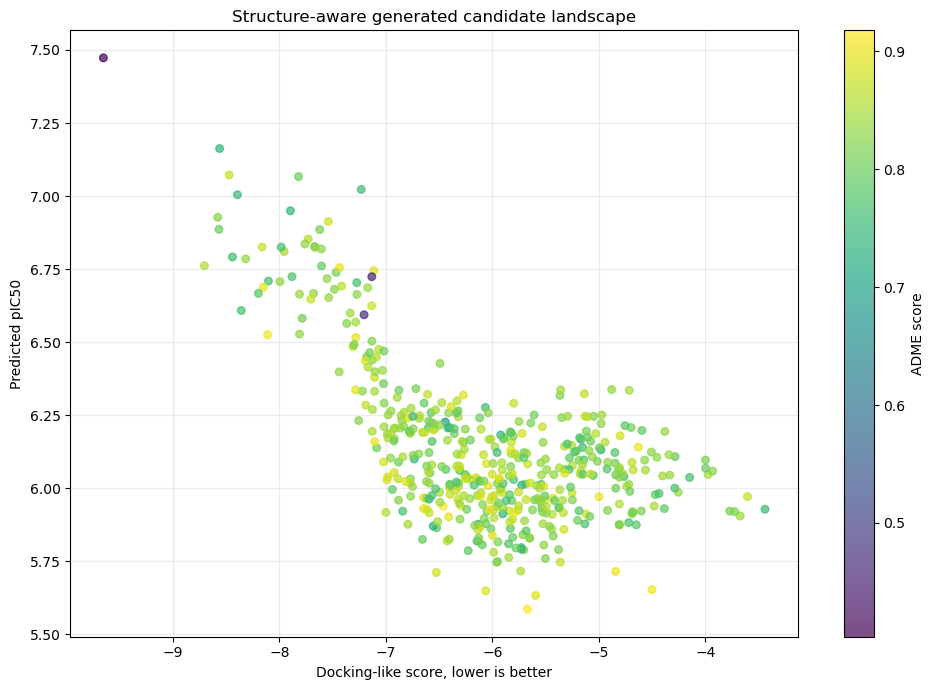

Saved: generative_ai4dd_outputs/figures/04_generated_uncertainty_domain_map.png


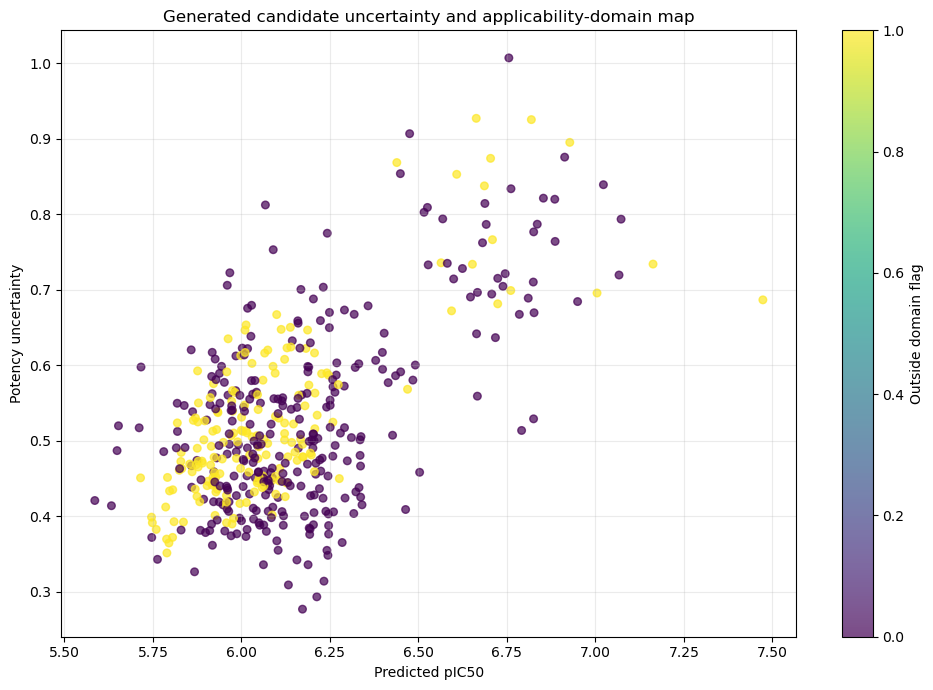

In [35]:
plt.figure(figsize=(14,8))
for i,col in enumerate(['MW','cLogP','TPSA','predicted_pIC50','adme_score','generative_priority_score'], 1):
    plt.subplot(2,3,i)
    plt.hist(gen_labeled[col], bins=30, alpha=0.85)
    plt.xlabel(col); plt.ylabel('Count'); plt.title(col); plt.grid(alpha=0.25)
plt.suptitle('Generated candidate property distributions', fontsize=16, y=1.02)
savefig('01_generated_candidate_distributions.png'); plt.show()

plt.figure(figsize=(10,7))
sc = plt.scatter(gen_labeled['predicted_pIC50'], gen_labeled['adme_score'], c=gen_labeled['generative_priority_score'], s=30, alpha=0.70)
plt.scatter(top_generated['predicted_pIC50'], top_generated['adme_score'], s=110, facecolors='none', edgecolors='black', linewidths=1.4, label='Top candidates')
plt.xlabel('Predicted pIC50'); plt.ylabel('ADME score'); plt.title('Generated molecule potency versus ADME landscape')
plt.colorbar(sc, label='Generative priority score'); plt.grid(alpha=0.25); plt.legend(); savefig('02_generated_potency_adme_landscape.png'); plt.show()

plt.figure(figsize=(10,7))
sc = plt.scatter(gen_labeled['docking_score'], gen_labeled['predicted_pIC50'], c=gen_labeled['adme_score'], s=30, alpha=0.70)
plt.xlabel('Docking-like score, lower is better'); plt.ylabel('Predicted pIC50'); plt.title('Structure-aware generated candidate landscape')
plt.colorbar(sc, label='ADME score'); plt.grid(alpha=0.25); savefig('03_generated_docking_potency_landscape.png'); plt.show()

plt.figure(figsize=(10,7))
sc = plt.scatter(gen_labeled['predicted_pIC50'], gen_labeled['potency_uncertainty'], c=gen_labeled['outside_domain'], s=30, alpha=0.70)
plt.xlabel('Predicted pIC50'); plt.ylabel('Potency uncertainty'); plt.title('Generated candidate uncertainty and applicability-domain map')
plt.colorbar(sc, label='Outside domain flag'); plt.grid(alpha=0.25); savefig('04_generated_uncertainty_domain_map.png'); plt.show()

# 12. Chemical-space comparison, seed versus generated molecules

Saved: generative_ai4dd_outputs/figures/05_seed_vs_generated_pca_space.png


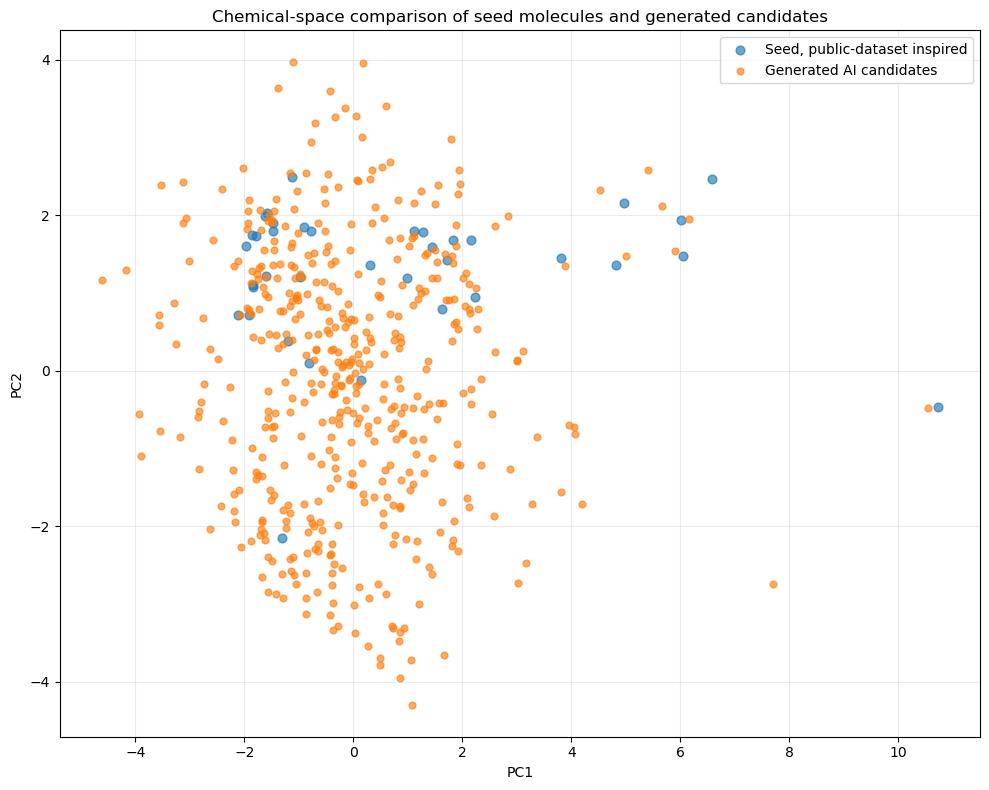

In [38]:
common = ['MW','cLogP','HBD','HBA','TPSA','rotatable_bonds','aromatic_rings','fraction_sp3','docking_score','adme_score']
seed_plot = seed_labeled[common].copy(); seed_plot['set']='Seed, public-dataset inspired'
gen_plot = gen_labeled[common].copy(); gen_plot['set']='Generated AI candidates'
plot_df = pd.concat([seed_plot, gen_plot], ignore_index=True)
P = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(StandardScaler().fit_transform(plot_df[common].fillna(0)))
plot_df['PC1'], plot_df['PC2'] = P[:,0], P[:,1]
plt.figure(figsize=(10,8))
for label in plot_df['set'].unique():
    s = plot_df[plot_df['set']==label]
    plt.scatter(s['PC1'], s['PC2'], s=40 if 'Seed' in label else 24, alpha=0.65, label=label)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Chemical-space comparison of seed molecules and generated candidates')
plt.grid(alpha=0.25); plt.legend(); savefig('05_seed_vs_generated_pca_space.png'); plt.show()

# 13. Novelty and diversity analysis

In [59]:
# Suppress RDKit SMILES parse warnings/errors in notebook output
try:
    from rdkit import RDLogger
    RDLogger.DisableLog("rdApp.*")
except Exception:
    pass

# Optional, also suppress Python warnings from descriptor conversion
import warnings
warnings.filterwarnings("ignore")

# Build generated molecule table
generated_df = pd.DataFrame({"smiles": raw_generated})

# Calculate descriptors quietly
gen_desc = generated_df["smiles"].apply(mol_descriptors).apply(pd.Series)

# Combine SMILES and descriptors
generated = pd.concat([generated_df, gen_desc], axis=1)

# Keep valid molecules only, remove duplicate canonical SMILES, and make an explicit copy
generated = (
    generated.loc[generated["valid"].eq(True)]
    .dropna(subset=["canonical_smiles"])
    .drop_duplicates(subset="canonical_smiles")
    .reset_index(drop=True)
    .copy()
)

# Mark novelty relative to seed molecules
seed_smiles_set = set(seed_labeled["canonical_smiles"].dropna())
generated.loc[:, "novel_vs_seed"] = ~generated["canonical_smiles"].isin(seed_smiles_set)

# Assign target labels reproducibly
targets = ["LDHA", "ATR", "RAD52", "POLQ", "KRAS_G12D", "PI3K_alpha"]
rng = np.random.default_rng(RANDOM_STATE)

generated.loc[:, "target"] = rng.choice(targets, size=len(generated))
generated.loc[:, "source_inspired"] = "generated_AI"

# Report summary
valid_count = len(generated)
novel_fraction = round(float(generated["novel_vs_seed"].mean()), 3) if valid_count else 0

print("Valid generated unique molecules:", valid_count)
print("Novel fraction:", novel_fraction)

display(generated.head(12))

Valid generated unique molecules: 479
Novel fraction: 0.923


,smiles,valid,MW,cLogP,HBD,HBA,TPSA,rotatable_bonds,aromatic_rings,fraction_sp3,QED,canonical_smiles,novel_vs_seed,target,source_inspired
0,COc1ccc1,True,82.102,1.08650,0.0,1.0,9.23,1.0,0.0,0.200000,0.459711,COC1=CC=C1,True,LDHA,generated_AI
1,Cc1ccc1O,True,82.102,1.38820,1.0,1.0,20.23,0.0,0.0,0.200000,0.467823,CC1=CC=C1O,True,KRAS_G12D,generated_AI
2,COc1ccccc1O,True,124.139,1.40080,1.0,2.0,29.46,1.0,1.0,0.142857,0.612773,COc1ccccc1O,False,POLQ,generated_AI
3,CCN1CCN(CC)C(=O)c1,True,156.229,0.17040,0.0,2.0,23.55,2.0,0.0,0.875000,0.568768,CCN1CCN(CC)C(=O)C1,True,RAD52,generated_AI
4,COc1cc(F)c(Cl)cc1,True,160.575,2.48770,0.0,1.0,9.23,1.0,1.0,0.142857,0.613494,COc1ccc(Cl)c(F)c1,True,RAD52,generated_AI
5,Cc1ccccc1,True,92.141,1.99502,0.0,0.0,0.00,0.0,1.0,0.142857,0.458806,Cc1ccccc1,True,PI3K_alpha,generated_AI
6,CCOCCOC(=O)c1cccc(F)c1,True,212.220,2.01900,0.0,3.0,35.53,5.0,1.0,0.363636,0.552974,CCOCCOC(=O)c1cccc(F)c1,True,LDHA,generated_AI
7,CN1CCOCC1,True,101.149,-0.05160,0.0,2.0,12.47,0.0,0.0,1.000000,0.423889,CN1CCOCC1,True,KRAS_G12D,generated_AI
8,Cc1ccc1,True,66.103,1.50250,0.0,0.0,0.00,0.0,0.0,0.200000,0.401713,CC1=CC=C1,True,ATR,generated_AI
9,Cc1cccc(Nc2ncnc12)N1CCN(CC)C(=O)c1,True,285.351,0.86570,1.0,5.0,60.30,2.0,0.0,0.400000,0.818589,CCN1CCN(C2=CC=CC(C)=C3N=CN=C3N2)CC1=O,True,LDHA,generated_AI


# 14. Agentic triage for generated candidates

,canonical_smiles,target,predicted_pIC50,adme_score,hERG_risk,potency_uncertainty,novelty_score,outside_domain,generative_priority_score,agent_decision,agent_rationale,agent_next_action
0,COc1ccc(F)c(NC(=O)N2CCC(c3nnc(-c4ccccc4)o3)CC2)c1,RAD52,6.949540,0.741726,0.942911,0.684101,0.250000,0,0.595913,Advance,moderate predicted potency; favourable ADME-li...,"reduce cLogP, aromaticity, or basic amine burd..."
1,Cc1ccc(-c2nc3ccc(S(=O)(=O)N4CCOCC4)cc3[nH]2)cn1,ATR,6.825188,0.768938,0.549545,0.528776,0.000000,0,0.569268,Advance,moderate predicted potency; favourable ADME-li...,"advance to confirmatory assay, docking pose re..."
2,O=C(Nc1ncccn1)Oc1ccccc1,RAD52,6.717387,0.827565,0.262701,0.636338,0.695652,0,0.567846,Advance,moderate predicted potency; favourable ADME-li...,prioritise for active learning if chemically i...
3,CC1=CC=C(NC(=O)c2ccc(Nc3ncccn3)cc2)CC1,PI3K_alpha,6.784968,0.836202,0.555160,0.667157,0.529412,0,0.567265,Advance,moderate predicted potency; favourable ADME-li...,"reduce cLogP, aromaticity, or basic amine burd..."
4,O=S(=O)(Nc1ccccc1)Oc1ccccc1,LDHA,6.824379,0.846272,0.357937,0.709952,0.700000,0,0.557058,Advance,moderate predicted potency; favourable ADME-li...,prioritise for active learning if chemically i...
5,Nc1ccc(NC(=O)Nc2ccccc2)cc1,LDHA,6.826547,0.747892,0.800684,0.669299,0.731707,0,0.556778,Advance,moderate predicted potency; favourable ADME-li...,"reduce cLogP, aromaticity, or basic amine burd..."
6,CCOC(=O)S(=O)(=O)Nc1ccc(C(F)(F)F)cc1,LDHA,6.885064,0.809889,0.599145,0.819637,0.666667,0,0.556643,Advance,moderate predicted potency; favourable ADME-li...,"reduce cLogP, aromaticity, or basic amine burd..."
7,c1ccc(OCCc2ncccn2)cc1,POLQ,6.646927,0.874322,0.275685,0.690133,0.783784,0,0.553777,Advance,moderate predicted potency; favourable ADME-li...,prioritise for active learning if chemically i...
8,NS(=O)(=O)c1ccc(COc2ccccc2)cc1,LDHA,6.463651,0.804428,0.448462,0.408704,0.482759,0,0.552815,Advance,low predicted potency; favourable ADME-like pr...,optimise potency through scaffold or substitue...
9,FC(F)(F)c1ccc(ONc2ccccc2)cc1,LDHA,6.852899,0.858603,0.576365,0.821037,0.804348,0,0.551876,Advance,moderate predicted potency; favourable ADME-li...,"reduce cLogP, aromaticity, or basic amine burd..."


Saved: generative_ai4dd_outputs/figures/07_agentic_triage_decisions.png


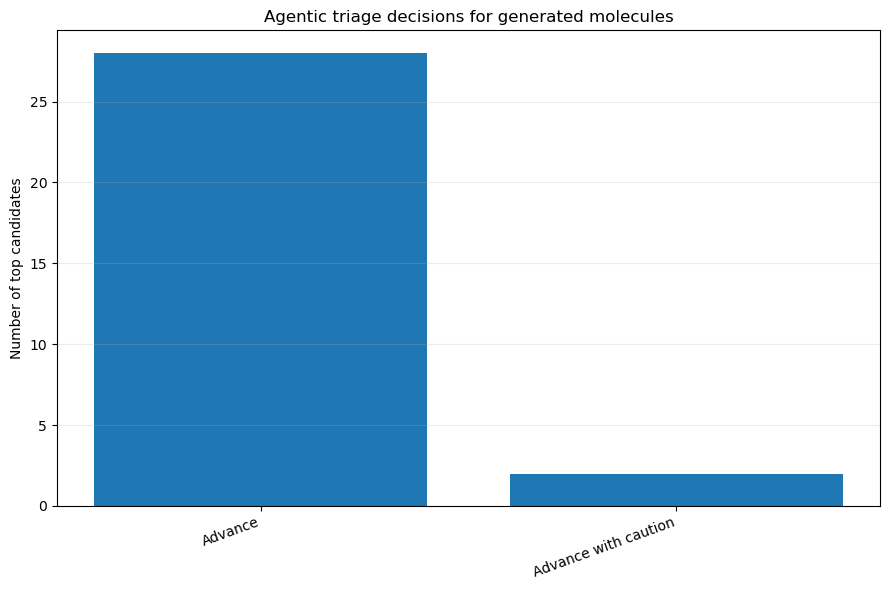

In [44]:
class GeneratedMoleculeTriageAgent:
    def triage(self, row):
        rationale, action = [], []
        if row['predicted_pIC50'] >= 7.5: rationale.append('high predicted potency')
        elif row['predicted_pIC50'] >= 6.5: rationale.append('moderate predicted potency')
        else:
            rationale.append('low predicted potency'); action.append('optimise potency through scaffold or substituent modification')
        if row['adme_score'] >= 0.70: rationale.append('favourable ADME-like profile')
        elif row['adme_score'] >= 0.55: rationale.append('acceptable but improvable ADME-like profile')
        else:
            rationale.append('ADME-like liability'); action.append('improve polarity, lipophilicity, or permeability balance')
        if row['hERG_risk'] > 0.55:
            rationale.append('elevated hERG-like risk'); action.append('reduce cLogP, aromaticity, or basic amine burden')
        if row['synthetic_accessibility_like'] > 6.5:
            rationale.append('synthetic complexity'); action.append('simplify scaffold')
        if row['outside_domain'] == 1:
            rationale.append('outside applicability domain'); action.append('treat as exploratory and check nearest neighbours')
        if row['potency_uncertainty'] > gen_labeled['potency_uncertainty'].quantile(0.75):
            rationale.append('high prediction uncertainty'); action.append('prioritise for active learning if chemically interesting')
        if row['novelty_score'] > 0.45:
            rationale.append('substantial novelty relative to seed corpus')
        if not action:
            action.append('advance to confirmatory assay, docking pose review, and orthogonal biophysical validation')
        if row['generative_priority_score'] >= gen_labeled['generative_priority_score'].quantile(0.90) and row['outside_domain']==0:
            decision='Advance'
        elif row['generative_priority_score'] >= gen_labeled['generative_priority_score'].quantile(0.75):
            decision='Advance with caution'
        elif row['potency_uncertainty'] > gen_labeled['potency_uncertainty'].quantile(0.75):
            decision='Active-learning candidate'
        elif row['generative_priority_score'] >= gen_labeled['generative_priority_score'].quantile(0.50):
            decision='Optimise'
        else:
            decision='Deprioritise'
        return pd.Series({'agent_decision':decision, 'agent_rationale':'; '.join(rationale), 'agent_next_action':'; '.join(action)})

triage = gen_labeled.apply(GeneratedMoleculeTriageAgent().triage, axis=1)
gen_triaged = pd.concat([gen_labeled.reset_index(drop=True), triage.reset_index(drop=True)], axis=1)
top_triaged = gen_triaged.sort_values('generative_priority_score', ascending=False).head(30).reset_index(drop=True)
display(top_triaged[['canonical_smiles','target','predicted_pIC50','adme_score','hERG_risk','potency_uncertainty','novelty_score','outside_domain','generative_priority_score','agent_decision','agent_rationale','agent_next_action']].head(20))

decision_counts = top_triaged['agent_decision'].value_counts()
plt.figure(figsize=(9,6)); plt.bar(decision_counts.index, decision_counts.values); plt.xticks(rotation=20, ha='right')
plt.ylabel('Number of top candidates'); plt.title('Agentic triage decisions for generated molecules'); plt.grid(axis='y', alpha=0.25)
savefig('07_agentic_triage_decisions.png'); plt.show()
gen_triaged.to_csv(TABLE_DIR/'generated_candidates_agentic_triage.csv', index=False)

# 15. Explainable AI for generated molecules

,feature,importance
0,docking_score,0.333412
1,MW,0.097775
2,fraction_sp3,0.068278
3,permeability,0.064410
4,hERG_risk,0.059199
5,cLogP,0.049948
6,hydrophobic_contacts,0.045940
7,shape_complementarity,0.045607
8,synthetic_accessibility_like,0.043767
9,pi_stacking,0.041753


Saved: generative_ai4dd_outputs/figures/08_surrogate_feature_importance.png


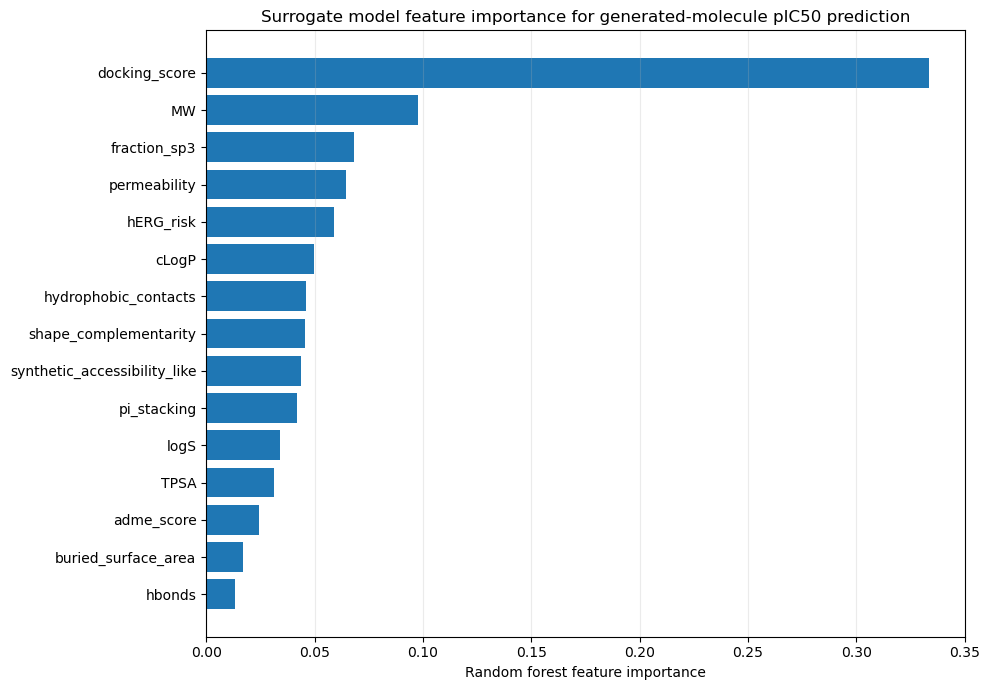

Top generated molecule
SMILES: COc1ccc(F)c(NC(=O)N2CCC(c3nnc(-c4ccccc4)o3)CC2)c1
Target: RAD52
Predicted pIC50: 6.95
Agent decision: Advance

Local explanation:
- docking_score: -7.9, below seed median -6.27
- MW: 396, above seed median 212
- fraction_sp3: 0.286, above seed median 0.273
- permeability: 0.747, above seed median 0.713
- hERG_risk: 0.943, above seed median 0.252
- cLogP: 4.3, above seed median 2.17
- hydrophobic_contacts: 6, above seed median 4
- shape_complementarity: 0.577, below seed median 0.594


In [61]:
# Surrogate model feature importance
importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance": reg_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance.head(15))

# Plot top feature importances
plt.figure(figsize=(10, 7))

top_imp = importance.head(15).iloc[::-1]

plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Random forest feature importance")
plt.title("Surrogate model feature importance for generated-molecule pIC50 prediction")
plt.grid(axis="x", alpha=0.25)

savefig("08_surrogate_feature_importance.png")
plt.show()


def explain_generated_candidate(row, n=8):
    """
    Explain a generated molecule by comparing its most important
    model-driving features against the median values in the seed set.
    """
    top_features = importance.head(n)["feature"].tolist()
    lines = []

    for feat in top_features:
        val = float(row[feat])
        ref = float(seed_labeled[feat].median())

        direction = "above" if val > ref else "below"

        lines.append(
            f"{feat}: {val:.3g}, {direction} seed median {ref:.3g}"
        )

    return lines


# Explain the top-ranked generated molecule
example = top_triaged.iloc[0]

print("Top generated molecule")
print("SMILES:", example["canonical_smiles"])
print("Target:", example["target"])
print("Predicted pIC50:", round(float(example["predicted_pIC50"]), 3))
print("Agent decision:", example["agent_decision"])

print("\nLocal explanation:")

for line in explain_generated_candidate(example):
    print("-", line)

# Export feature importance table
importance.to_csv(TABLE_DIR / "surrogate_feature_importance.csv", index=False)

# 16. Active-learning selection for the next experimental round

,canonical_smiles,target,predicted_active_probability,predicted_pIC50,potency_uncertainty,adme_score,novelty_score,active_learning_score,agent_decision
181,FC(F)(F)c1ccc(ONc2ccccc2)cc1,LDHA,0.568010,6.852899,0.821037,0.858603,0.804348,0.700993,Advance
134,Nc1ccc(C(=O)NCN2CCNCC2)cc1,KRAS_G12D,0.533294,6.663187,0.926789,0.826107,0.709091,0.683508,Active-learning candidate
289,Oc1ccc(COc2ccccc2)cc1,RAD52,0.474191,6.687641,0.814028,0.896092,0.742857,0.680105,Advance
175,Clc1ccc(NC2COCCN2)cc1,RAD52,0.417963,6.912954,0.875370,0.877901,0.815789,0.679957,Advance
216,CCOC(=O)S(=O)(=O)Nc1ccc(C(F)(F)F)cc1,LDHA,0.594145,6.885064,0.819637,0.809889,0.666667,0.679198,Advance
79,FC(F)(F)c1ccc(CCOc2ccccc2)cc1,KRAS_G12D,0.611771,6.652372,0.733529,0.839261,0.809524,0.678988,Advance with caution
381,NS(=O)(=O)c1ccc(NC2COCCN2)cc1,PI3K_alpha,0.632683,6.703732,0.873799,0.764664,0.692308,0.678001,Advance with caution
103,Clc1ccc(Nc2ccccc2)cc1,LDHA,0.499744,6.691379,0.786292,0.866827,0.785714,0.672303,Advance
233,Clc1ccc(ONc2ccccc2)cc1,KRAS_G12D,0.428629,6.515792,0.802353,0.889791,0.783784,0.668402,Advance with caution
397,CCOC(=O)NC(=O)N1CCOCC1,ATR,0.483952,6.818898,0.925077,0.831210,0.682927,0.664621,Active-learning candidate


Saved: generative_ai4dd_outputs/figures/09_active_learning_generated_candidates.png


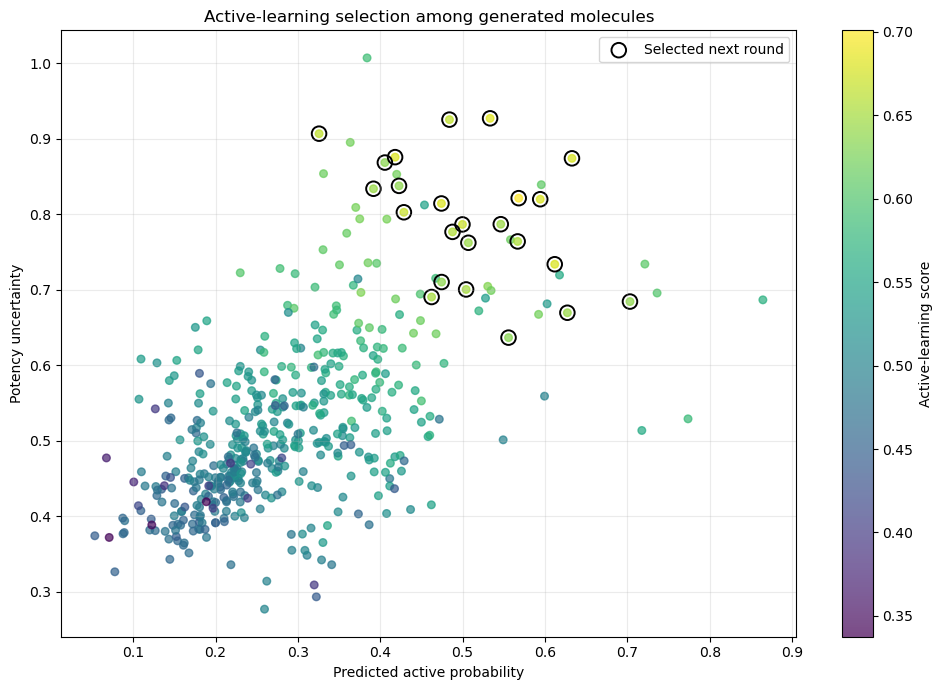

In [50]:
gen_triaged['active_learning_score'] = 0.25*gen_triaged['predicted_active_probability'] + 0.25*np.clip(gen_triaged['potency_uncertainty']/(gen_triaged['potency_uncertainty'].max()+1e-9),0,1) + 0.20*gen_triaged['adme_score'] + 0.15*gen_triaged['novelty_score'] + 0.10*np.clip(gen_triaged['diversity_proxy']/(gen_triaged['diversity_proxy'].max()+1e-9),0,1) + 0.05*gen_triaged['domain_score']
active_learning_set = gen_triaged.sort_values('active_learning_score', ascending=False).head(24)
display(active_learning_set[['canonical_smiles','target','predicted_active_probability','predicted_pIC50','potency_uncertainty','adme_score','novelty_score','active_learning_score','agent_decision']])
active_learning_set.to_csv(TABLE_DIR/'active_learning_next_round_candidates.csv', index=False)

plt.figure(figsize=(10,7))
sc = plt.scatter(gen_triaged['predicted_active_probability'], gen_triaged['potency_uncertainty'], c=gen_triaged['active_learning_score'], s=30, alpha=0.70)
plt.scatter(active_learning_set['predicted_active_probability'], active_learning_set['potency_uncertainty'], s=110, facecolors='none', edgecolors='black', linewidths=1.4, label='Selected next round')
plt.xlabel('Predicted active probability'); plt.ylabel('Potency uncertainty'); plt.title('Active-learning selection among generated molecules')
plt.colorbar(sc, label='Active-learning score'); plt.grid(alpha=0.25); plt.legend(); savefig('09_active_learning_generated_candidates.png'); plt.show()

# 17. Export manuscript-ready tables and molecule grids

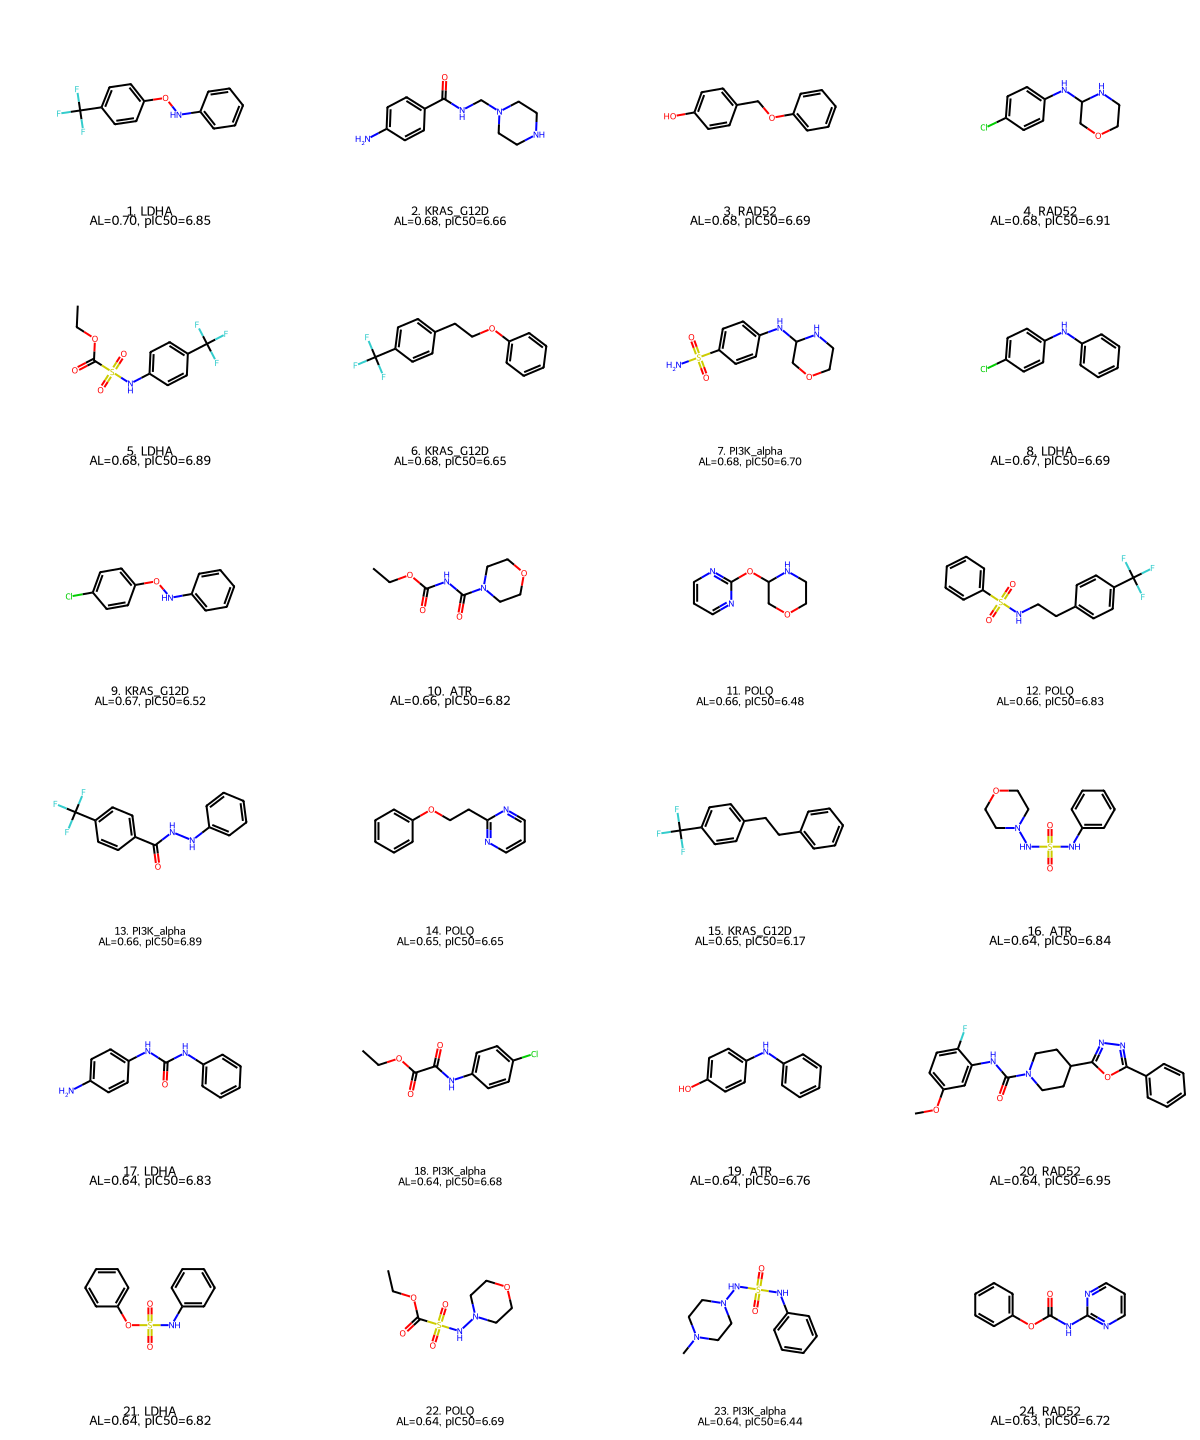

Saved: generative_ai4dd_outputs/molecule_images/active_learning_molecule_grid.png
Exported tables:
- generative_ai4dd_outputs/tables/active_learning_next_round_candidates.csv
- generative_ai4dd_outputs/tables/all_generated_scored_candidates.csv
- generative_ai4dd_outputs/tables/generated_candidates_agentic_triage.csv
- generative_ai4dd_outputs/tables/seed_public_dataset_inspired_training_set.csv
- generative_ai4dd_outputs/tables/supplementary_table_top_generated_triaged_candidates.csv
- generative_ai4dd_outputs/tables/surrogate_feature_importance.csv
- generative_ai4dd_outputs/tables/top_generated_candidates.csv
Exported figures:
- generative_ai4dd_outputs/figures/01_generated_candidate_distributions.png
- generative_ai4dd_outputs/figures/02_generated_potency_adme_landscape.png
- generative_ai4dd_outputs/figures/03_generated_docking_potency_landscape.png
- generative_ai4dd_outputs/figures/04_generated_uncertainty_domain_map.png
- generative_ai4dd_outputs/figures/05_seed_vs_generated_pc

In [63]:
main_cols = [
    "canonical_smiles",
    "target",
    "predicted_pIC50",
    "predicted_active_probability",
    "docking_score",
    "adme_score",
    "hERG_risk",
    "synthetic_accessibility_like",
    "potency_uncertainty",
    "novelty_score",
    "outside_domain",
    "generative_priority_score",
    "agent_decision",
    "agent_rationale",
    "agent_next_action"
]

# Export supplementary table
top_triaged[main_cols].to_csv(
    TABLE_DIR / "supplementary_table_top_generated_triaged_candidates.csv",
    index=False
)

if RDKIT_AVAILABLE:
    # Build valid molecule list only
    mol_records = []

    for i, row in active_learning_set.head(24).iterrows():
        mol = Chem.MolFromSmiles(row["canonical_smiles"])

        if mol is not None:
            mol_records.append((mol, row))

    mols = [x[0] for x in mol_records]

    legends = [
        f"{j + 1}. {row.target}\nAL={row.active_learning_score:.2f}, pIC50={row.predicted_pIC50:.2f}"
        for j, (_, row) in enumerate(mol_records)
    ]

    # Force RDKit to return a PIL image, not an SVG/IPython object
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=4,
        subImgSize=(300, 240),
        legends=legends,
        useSVG=False
    )

    display(img)

    output_path = MOL_DIR / "active_learning_molecule_grid.png"

    # Save robustly
    if hasattr(img, "save"):
        img.save(str(output_path))
    else:
        # Fallback for IPython Image-like objects
        with open(output_path, "wb") as f:
            f.write(img.data)

    print("Saved:", output_path)

print("Exported tables:")
for p in sorted(TABLE_DIR.glob("*.csv")):
    print("-", p)

print("Exported figures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print("-", p)

# 18. How to replace the synthetic layer with BindingDB, ChEMBL, and PDBbind

## BindingDB

Use BindingDB for experimentally measured protein-ligand affinity records, including Ki, Kd, IC50, and EC50. Standardise units to molar values and transform them into pActivity values such as pIC50 or pKd. Remove ambiguous records when needed, track assay provenance, and separate target-specific and pan-target models.

## ChEMBL

Use ChEMBL for curated bioactivity, target metadata, assay confidence scores, and medicinal-chemistry annotations. Recommended curation includes salt stripping, molecule neutralisation where appropriate, duplicate handling, assay-confidence filtering, target-confidence filtering, pChEMBL extraction, and scaffold-based splitting.

## PDBbind

Use PDBbind-style records for protein-ligand complexes with structural binding-affinity labels. Structure-aware features can include docking scores, hydrogen bonds, hydrophobic contacts, buried surface area, electrostatics, ligand strain, water-network terms, and shape complementarity.

## Real-data extension

The generated candidates from this notebook should be treated as computational hypotheses. Real validation would require docking pose review, orthogonal biochemical assays, biophysical binding assays, cellular assays, ADME profiling, safety screening, and medicinal-chemistry review.

# 19. Manuscript-ready interpretation

This generative extension shows how a simulated AI4DD workflow can move from prediction to candidate design. At the **molecular level**, the workflow connects SMILES generation, molecular descriptors, hydrogen bonding, hydrophobic contacts, shape complementarity, docking-like scores, ADME-like properties, and predicted potency. At the **systems level**, it links data curation, generative sampling, molecular validation, surrogate prediction, explainability, uncertainty, novelty assessment, active learning, and agentic triage into a reproducible decision-support pipeline.

The generated molecules should be presented as **hypothesis-generating candidates**, not validated inhibitors. The value of the notebook is methodological: it demonstrates how BindingDB-, ChEMBL-, and PDBbind-ready data streams could be connected to generative AI, explainable ML, and medicinal-chemistry decision support.